In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# !pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/matheusmsgomes/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1


In [7]:
import os

# look at all data files
print(os.listdir(path))

['UCI_Credit_Card.csv']


In [8]:
# ebuild full path and load it
file_name = "UCI_Credit_Card.csv"
file_path = os.path.join(path, file_name)

df = pd.read_csv(file_path)

## DATA CLEANING

In [9]:
# initial inspection of data frame
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0 

In [10]:
# check missing values
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

- Pay close attention to default.payment.next.month, PAY_AMT2, and EDUCATION for possible issues
- drop ID as it gives no predictive power (index variable)
- no missing values or non-plausible values in the data
- categorical variables are already in numerical form. no need to format

In [11]:
# drop ID column
df = df.drop('ID', axis=1)

In [12]:
# rename columns for clarity
df = df.rename(columns={
    "default.payment.next.month": "default",
    "PAY_0": "PAY_1"
})

In [13]:
# remove duplicates
df.duplicated().sum()
df = df.drop_duplicates()

In [14]:
# merge 0, 5, and 6 since they are both "unknown" category
# keep "unknown" separate from "other"
df["EDUCATION"] = df["EDUCATION"].replace({0: 5, 5: 5, 6: 5})

# verify
df["EDUCATION"].value_counts()

EDUCATION
2    14019
1    10563
3     4915
5      345
4      123
Name: count, dtype: int64

In [15]:
# MARRIAGE cleanup
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

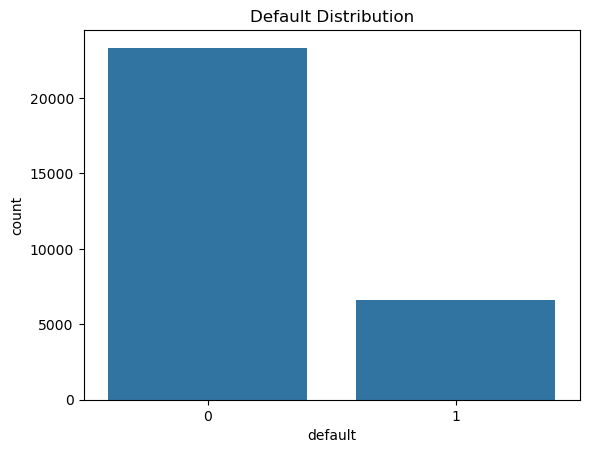

In [16]:
# check target variable distribution
sns.countplot(x="default", data=df)
plt.title("Default Distribution")
plt.show()

- target variable imbalance. address inmediately to avoid bias in the model
- use resampling technique or other

In [17]:
# understand class imbalance
df["default"].value_counts(normalize=True)

default
0    0.778742
1    0.221258
Name: proportion, dtype: float64

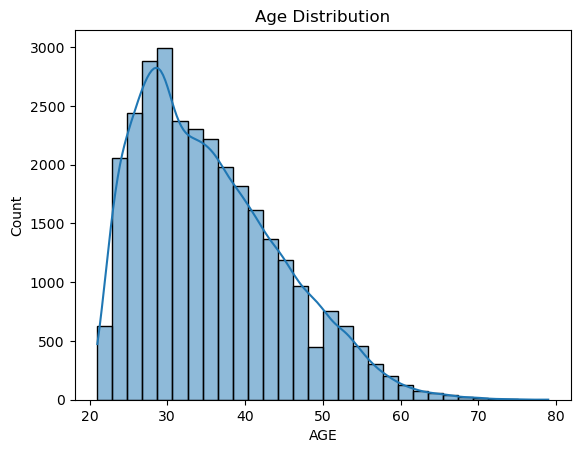

In [18]:
# AGE distribution
sns.histplot(df["AGE"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

- skewness to the right. consider transformation

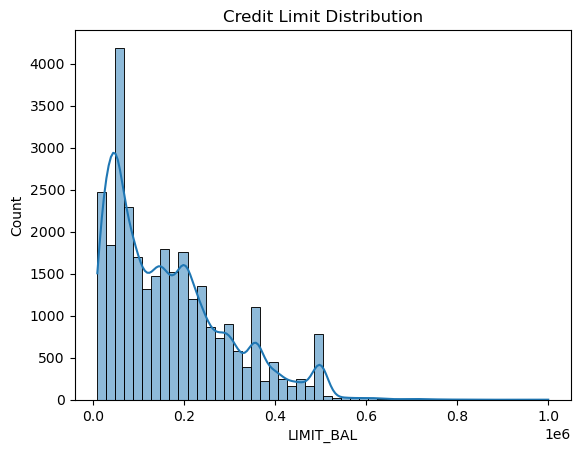

In [19]:
# credit limit distribution
sns.histplot(df["LIMIT_BAL"], bins=50, kde=True)
plt.title("Credit Limit Distribution")
plt.show()

- once again skewness to the right. consdier transformation.
- more unstable than age distribution

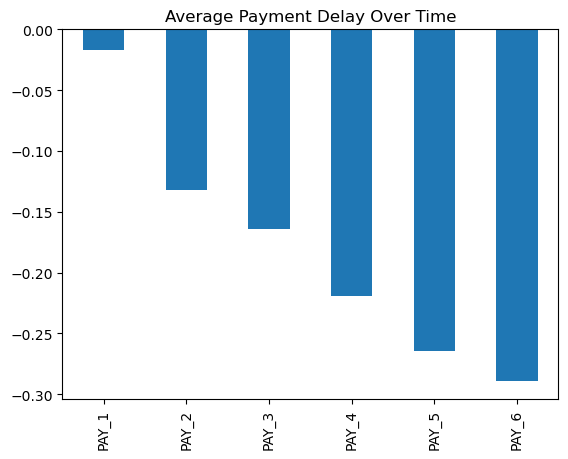

In [20]:
# payment status each month analysis
pay_cols = ["PAY_1","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

df[pay_cols].mean().plot(kind="bar")
plt.title("Average Payment Delay Over Time")
plt.show()

- this graph tells us that loaners tend to struggle more and more as they grow debt continuously each month

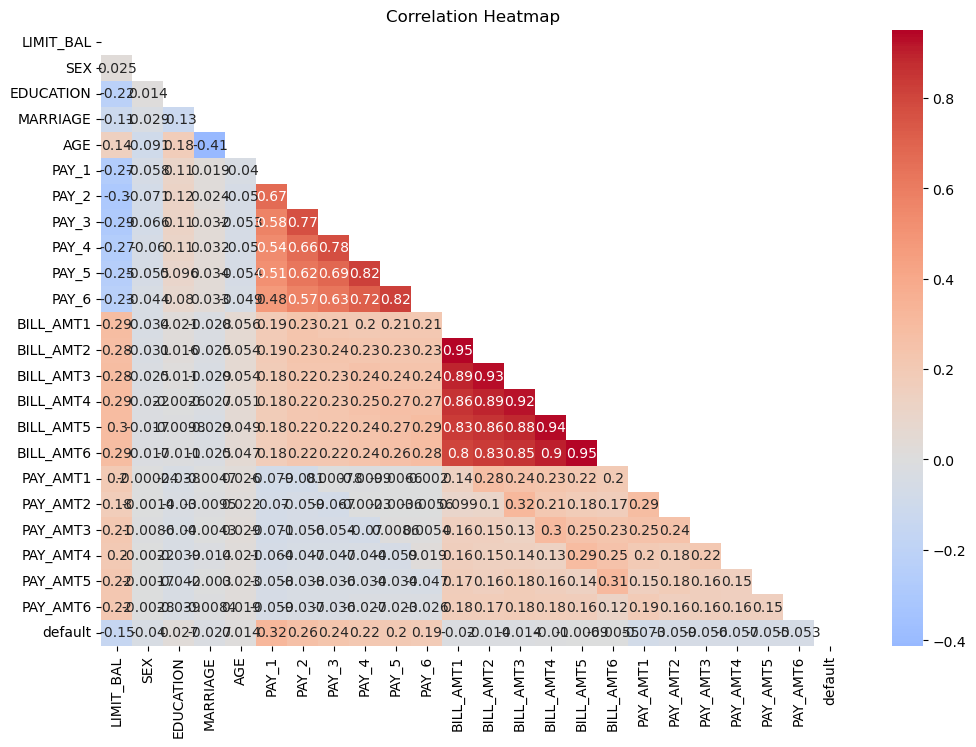

In [21]:
# heatmap correlation
plt.figure(figsize=(12,8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap")
plt.show()

- be mindful of potential multicollinearity issues.
- high correlation between features makes it impossible to determine the individual importance of variables. interpretability problem


## FEATURE ENGINEERING

In [53]:
bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
            "BILL_AMT4","BILL_AMT5","BILL_AMT6"]

pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
                "PAY_AMT4","PAY_AMT5","PAY_AMT6"]

In [54]:
# total bill amount
df["TOTAL_BILL"] = df[bill_cols].sum(axis=1)

In [55]:
# total payment amount
df["TOTAL_PAY"] = df[pay_amt_cols].sum(axis=1)

In [56]:
# payment ratio (signal)
df["PAY_RATIO"] = df["TOTAL_PAY"] / (df["TOTAL_BILL"] + 1) # +1 to avoid division by 0

In [57]:
# credit utilization (debt to limit percentage)
df["UTILIZATION"] = df["TOTAL_BILL"] / (df["LIMIT_BAL"] + 1)

In [58]:
# log transform for skewed variables
df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])
df["AGE_LOG"] = np.log1p(df["AGE"])

In [59]:
'''
save csv of clean dataset
import os

folder_path = r"C:\Users\matheusmsgomes\Downloads"
file_path = os.path.join(folder_path, "cleaned_credit_data_v1.csv") '''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 56-57: truncated \UXXXXXXXX escape (535705057.py, line 1)

In [ ]:
# df.to_csv(file_path, index=False)

In [ ]:
folder_path = "/Users/matheusmsgomes/Downloads"
file_path = os.path.join(folder_path, "cleaned_credit_data_v1.csv")
df.to_csv(file_path, index=False)
print(file_path)

/Users/matheusmsgomes/Downloads/cleaned_credit_data_v1.csv


In [ ]:
print(os.listdir(folder_path))

['cis4340-Lab01-mysqlMint (1).pdf', 'Matheus Santos Gomes 2.pdf', 'output (2).png', 'Matheus_ STA4724_HW5.ipynb', 'Cultural Expression Paper - Matheus Gomes.pdf', 'quiz 1 practice.pdf', 'ISC4242_HW1.pdf', 'Week7 Class Practice.ipynb', 'AnexoBNomeVoluntario (2).docx', 'MA 3 Response Letter Draft 1 (2).docx', 'Penguins (1).xlsx', 'DOC101125 (4).pdf', 'Lecture 8-9_Gradient Descent.pdf', 'OperaSetup.zip', 'Mini Project 2 (4).pdf', 'HW6 Answer Template.docx', 'cis4340 hw1 reqs.png', 'Amerant_Cover_Letter.docx', 'IMG_2613 (1).HEIC', 'Major Assignment 1 (3).pdf', '_tmp__lease_documents_20231130024115.pdf', 'Assignment 3.2.c', 'Club Tennis FSU Non-SCC Travel Roster (1).xlsx', '2026_ASA_Data_Challenge_HDL_Predictive_Modeling_Report.pdf', 'program 8 (1).py', 'STA4163 Mini Project 3 Sample Code.R', 'fighter_stats.csv', '.Rhistory', 'Tigers-Volleyball-Logo-1339-CA.webp', 'RStudio-2024.04.2-764.dmg', 'ToothGrowth Excel Formatted.xlsx_ STA4163-24Spring 0002.html', 'Conference Reflection (1).pdf', 'I

Interaction Variables to Create

In [ ]:
# Repayment Behavior Features

# average delay across 6 months
df["PAY_AVG"] = df[pay_cols].mean(axis=1)

# worst delay ever recorded
df["PAY_MAX"] = df[pay_cols].max(axis=1)

# recent worsening trend
df["PAY_TREND"] = df["PAY_1"] - df["PAY_6"]

These capture:

• consistent lateness\
• severe lateness\
• behavior getting worse recently

In [60]:
# Debt Behavior Features

# average monthly bill
df["AVG_BILL"] = df[bill_cols].mean(axis=1)

# bill volatility
df["BILL_STD"] = df[bill_cols].std(axis=1)

# debt increasing recently
df["BILL_TREND"] = df["BILL_AMT1"] - df["BILL_AMT6"]

In [61]:
# Payment Behavior Features

# average monthly payment
df["AVG_PAY"] = df[pay_amt_cols].mean(axis=1)

# payment consistency
df["PAY_STD"] = df[pay_amt_cols].std(axis=1)

In [62]:
# Best Interaction Terms
df["UTIL_X_PAY1"] = df["UTILIZATION"] * df["PAY_1"]
df["RATIO_X_PAY1"] = df["PAY_RATIO"] * df["PAY_1"]
df["LIMIT_X_UTIL"] = df["LIMIT_BAL_LOG"] * df["UTILIZATION"]
df["AGE_X_PAY1"] = df["AGE_LOG"] * df["PAY_1"]

In [68]:
# Checking which features matter most
corr_target = df.corr(numeric_only=True)["default"].sort_values(ascending=False)
print(corr_target.head(20))
print()
print(corr_target.tail(10))

default               1.000000
PAY_MAX               0.331082
PAY_1                 0.324964
AGE_X_PAY1            0.323116
UTIL_PAY1_INTERACT    0.316637
UTIL_X_PAY1           0.316637
PAY_AVG               0.281989
PAY_2                 0.263656
PAY_3                 0.235230
PAY_4                 0.216551
PAY_5                 0.204059
PAY_6                 0.186740
PAY_TREND             0.129303
UTILIZATION           0.115449
LIMIT_X_UTIL          0.102899
EDUCATION             0.026979
AGE                   0.013619
AGE_LOG               0.007301
RATIO_X_PAY1          0.003351
BILL_AMT6            -0.005469
Name: default, dtype: float64

PAY_AMT3        -0.056319
PAY_AMT4        -0.056898
PAY_AMT2        -0.058643
PAY_AMT1        -0.073015
PAY_STD         -0.074123
BILL_STD        -0.079981
AVG_PAY         -0.102488
TOTAL_PAY       -0.102488
LIMIT_BAL       -0.153871
LIMIT_BAL_LOG   -0.173722
Name: default, dtype: float64


The output is telling: 
| Feature     | Correlation with Default |
| ----------- | ------------------------ |
| PAY_MAX     | **0.331**                |
| PAY_1       | 0.325                    |
| AGE_X_PAY1  | 0.323                    |
| UTIL_X_PAY1 | 0.317                    |
| PAY_AVG     | 0.282                    |

Interpretation:

• PAY_MAX = Strongest Predictor

This means:The worst repayment status over 6 months matters more than any single month.

• UTIL_X_PAY1 is Elite Feature

High utilization + recent late payment = strong risk.

• GE_X_PAY1 Strong

Suggests age modifies repayment risk. Younger late payers may behave differently than older ones.

• LIMIT_BAL Negative Correlation

Higher credit limits linked with lower default. Likely stronger credit profiles.

In [69]:
# Top Predictors:
top_features = [
    "PAY_MAX",
    "PAY_1",
    "AGE_X_PAY1",
    "UTIL_X_PAY1",
    "PAY_AVG",
    "PAY_2",
    "PAY_3",
    "PAY_TREND",
    "UTILIZATION",
    "LIMIT_BAL_LOG",
    "AVG_PAY"
]